In [ ]:
import csv
import numpy as np
import time
import cupy as cp
import math
import matplotlib.pyplot as plt

In [ ]:
# simple function to parse the given csv file
def parse_csv(file_path) -> tuple[np.ndarray, np.ndarray]:
    with open(file_path, 'r') as f:
        r = csv.reader(f)

        x_values = []
        y_values = []

        for row in r:
            features = np.array([float(x) for x in row[:-1]])
            c = int(float(row[-1]))

            x_values.append(features)
            y_values.append(c)

        # in the end we have to np array, one for all x values (list of vectors with 7 features) and y values (list of the class of the vectors)
        return np.array(x_values, dtype=np.float32), np.array(y_values, dtype=np.int8)


In [ ]:

# kernel from prev. exercise modifed to do distance calculaiton
# however it shows that tiling and shared memory does not help with performance for this kind of problem
# we use 32 as tile size to have 1024 threads per block (32 * 32 = 1024)
tile_size = 32
distance_kernel_tiled = cp.RawKernel(r''' extern "C"

#define TILE_SIZE %TILE_SIZE%

__global__ void matrix_multiplication(const float* A, const float* B, float* C, int N, int M, int K)
  {

    // here we define the shared memory for the threads
    __shared__ float As[TILE_SIZE][TILE_SIZE];
    __shared__ float Bs[TILE_SIZE][TILE_SIZE];

    int tx = threadIdx.x;
    int ty = threadIdx.y;

    int row = blockIdx.y * TILE_SIZE + ty;
    int col = blockIdx.x * TILE_SIZE + tx;

    float sum = 0;

    // ceiling division to get the number of tiles needed
    // M is the shared dimension between A and B
    // num_tiles is the number of tiles (both from A and B) to perform the final multiplication
    int num_tiles = (M + TILE_SIZE - 1) / TILE_SIZE;

    // here we iterate throgh the number of tiles
    // and for each we load both a tile from a and b and multiply them toghter
    // the partial sum is updated each iterartion
    for(int t = 0; t < num_tiles; t++)
    {
      // calc the current rows and cols in both tiles
      int A_col = t * TILE_SIZE + tx;
      int B_row = t * TILE_SIZE + ty;

      // if we have a matrix which is not fully divisible by our tile size, we need to add padding (with zeros)
      if (row < N && A_col < M) {
        As[ty][tx] = A[row * M + A_col];
      } else {
        As[ty][tx] = 0.0;
      }

      // if we have a matrix which is not fully divisible by our tile size, we need to add padding (with zeros)
      if (B_row < M && col < K) {
        // B is transposed, so we need to swap the indices
        Bs[ty][tx] = B[col * M + B_row];
      } else {
        Bs[ty][tx] = 0.0;
      }

      // After this point both the tile from A and B are loaded in shared memory
      __syncthreads();

      // Do the final multiplication for the tile
      for(int k = 0; k < TILE_SIZE; k++)
      {
        // CHANGED: this line was changed to modfied the matrix multiplication into a distance calcuation
        sum += (As[ty][k] - Bs[k][tx]) * (As[ty][k] - Bs[k][tx]);
      }

      // wait for threads to finish, otherwise it could lead to override of the shared memory
      __syncthreads();

    }

    // after all tiles from A and B have been multiplied and accumulated in sum, we write back the final sum
    if(row < N && col < K)
    {
      // we skip the square root calculation here, since we only need distances
      // and the sqrt is no a performant operation
      C[row * K + col] = sum;
    }
  }

'''.replace("%TILE_SIZE%", str(tile_size)), 'matrix_multiplication')


In [ ]:
# instead kernel is a more simple version of the tiled kernel
# each thread calculated the distance for exactly one point
# no shared memory is used
distance_kernel = cp.RawKernel(r'''extern "C"

__global__ void distance_kernel(const float* A, const float* B, float* C, int N, int M) {
    int tx = threadIdx.x;
    int ty = threadIdx.y;

    int row = blockIdx.y * blockDim.y + ty;
    int col = blockIdx.x * blockDim.x + tx;

    if (row >= N || col >= M) return;

    float sum = 0.0f;

    // k is the number of features in the data
    // since we now that k == 7
    // the compiler can unroll the loop for us to further improve performance
    #pragma unroll
    for (int k = 0; k < 7; k++) {
        float a = A[row * 7 + k];
        float b = B[k * M + col];
        float d = a - b;
        sum += d * d;
    }

    C[row * M + col] = sum;
}
''', "distance_kernel")

In [ ]:
# knn_cpu:
# Perform kNN classification on a CPU using methods from Numpy
# x_vals: An array with the shape of (n, 7), where N is the number of given values from the training set. Each element must have 7 features
# classes: An array with the shape of (n, 1), where for every index n of x_vals the class of the value is given. Must have same size as x_vals. Index must match.
# samples: An array of samples to classify with the kNN-Method. Must in shape (m, 7). Each element must have 7 features
# batch_size: The number of batches that samples should be divided into
# Returns: A an array of shape (m, 1), with the found classes for each element of samples
def knn_cpu(x_vals: np.ndarray, classes: np.ndarray, samples: np.ndarray, k: int, batch_size: int) -> np.ndarray:
    results = np.empty(samples.shape[0], dtype=np.int8)
    # Cast inputs to float32 to match GPU precision for comparison
    x_vals_f32 = x_vals.astype(np.float32)
    classes_f32 = classes.astype(np.int8)
    samples_f32 = samples.astype(np.float32)

    # to limit the memory size during the computation
    # the samples matrix is divided into submaticies with a given batch_size
    # otherwise the distance matrix would be m*n*4 bytes large which is not feasible for large m or n.
    for i in range(0, samples_f32.shape[0], batch_size):
        batch_samples = samples_f32[i:i+batch_size]

        # samples is a batch with shape (n, 7)
        # x_vals is the training data with shape (m, 7)
        # the resulting matrix has shape (n,m) where for each sample (n) there are the distances to each training point (m)
        distances = np.linalg.norm(x_vals_f32 - batch_samples[:, np.newaxis], axis=2)
        # then we sort for every sample and have the indices of the nearest neighbors
        # in the shape (n, m) where for each sample (n) there are the indices of the training points sortedR by distance (m)
        min_distances = np.argpartition(distances, k, axis=1)[:, :k]
        # we take the k nearest neighbors for each sample
        # the result has the shape (n, k)
        nearest_classes = classes_f32[min_distances]
        # now we want reduce k to 1 by taking the most common class among the k nearest neighbors for each sample
        final_classes = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=1, arr=nearest_classes)
        results[i:i+batch_size] = final_classes

    return results

In [ ]:
# knn_cpu:
# Perform kNN classification on a GPU using methods from Numpy
# x_vals: An array with the shape of (n, 7), where N is the number of given values from the training set. Each element must have 7 features
# classes: An array with the shape of (n, 1), where for every index n of x_vals the class of the value is given. Must have same size as x_vals. Index must match.
# samples: An array of samples to classify with the kNN-Method. Must in shape (m, 7). Each element must have 7 features
# batch_size: The number of batches that samples should be divided into
# full_gpu: If majority vote should place on gpu instead of gpu
# tiled_kernel: If the tiled kernel should be used
# Returns: A an array of shape (m, 1), with the found classes for each element of samples
def knn_gpu(x_vals: np.ndarray, classes: np.ndarray, samples: np.ndarray, k: int, batch_size: int, full_gpu: bool, tiled_kernel: bool) -> np.ndarray:
    # on the GPU side, we first need to copy everything to GPU meemory
    x_vals = cp.array(x_vals, dtype=cp.float32)
    # this is needed for the second kernel
    x_vals_T = cp.ascontiguousarray(x_vals.T)
    classes = cp.array(classes, dtype=cp.int8)
    samples = cp.array(samples, dtype=cp.float32)
    # we create the matrix before to save on allocations
    distances = cp.empty((batch_size, x_val.shape[0]), dtype=cp.float32)

    # the results will either be written by GPU or by numpy, dependeing on the parameter
    if full_gpu:
      results = cp.empty(samples.shape[0], dtype=np.int8)
    else:
      results = np.empty(samples.shape[0], dtype=np.int8)

    # to limit the memory size during the computation
    # the samples matrix is divided into submaticies with a given batch_size
    # otherwise the distance matrix would be m*n*4 bytes large which is not feasible for large m or n.
    for i in range(0, samples.shape[0], batch_size):
        batch_samples = samples[i:i+batch_size]

        distances_rows = batch_samples.shape[0]
        distances_cols = x_vals.shape[0]

        tiles_x = math.ceil(distances_cols/tile_size)
        tiles_y = math.ceil(distances_rows/tile_size)
        # samples is a batch with shape (n, 7)
        # x_vals is the training data with shape (m, 7)
        # the resulting matrix has shape (n,m) where for each sample (n) there are the distances to each training point (m)

        # depening on the parameter we chose the corresponding kernel
        # each kernel is called on a 32x32 block
        # the number of blocks is calculated depening on the number of samples
        if tiled_kernel:
          distance_kernel_tiled((tiles_x, tiles_y,1),(tile_size,tile_size, 1),(batch_samples, x_vals, distances, np.int32(distances_rows), np.int32(batch_samples.shape[1]), np.int32(distances_cols)))
        else:
          distance_kernel((tiles_x, tiles_y,1),(tile_size,tile_size, 1),(batch_samples, x_vals_T, distances,np.int32(distances_rows),np.int32(distances_cols)))

        # then we sort for every sample and have the indices of the nearest neighbors
        # in the shape (n, m) where for each sample (n) there are the indices of the training points sortedR by distance (m)
        # (same as cpu version but with cupy)
        min_distances = cp.argpartition(distances[:distances_rows], k, axis=1)[:, :k]
        # we take the k nearest neighbors for each sample
        # the result has the shape (n, k)

        # this is a really expensive GPU operation, since it requries many kernel launches for only a small set of number
        # so it is toggable via a parameter
        if full_gpu:
          nearest_classes = classes[min_distances]
          # now we want reduce k to 1 by taking the most common class among the k nearest neighbors for each sample
          results[i:i+batch_size] = cp.array([cp.bincount(nearest_classes[i]).argmax() for i in range(nearest_classes.shape[0])])
        else:
          nearest_classes = cp.asnumpy(classes[min_distances])
          results[i:i+batch_size] = np.array([np.bincount(nearest_classes[i]).argmax() for i in range(nearest_classes.shape[0])])

    # if results is still in gpu memory, we need to convert it to a cpu implementation
    if full_gpu:
      return cp.asnumpy(results)
    else:
      return results

In [ ]:
# wrapper function to perform a test on the cpu
# x_val: the x_vals from the CSV
# y_val: the y_vals from the CSV
# min: lower limit for sample generation feature values
# max: upper limit for sample generation feature values
# k: number of values to include in kNN decison
# batch_size: Batch size
# returns: Second to perform computation, Results
def test_cpu(x_val, y_val, samples, min, max, k, batch_size=32):
    start = time.time()

    results = knn_cpu(x_val, y_val, np.random.uniform(min, max, size=(samples, 7)), k, batch_size)
    took = time.time() - start
    print(f"Took (CPU): {took}s (Samples = {samples})")
    return took, results


In [ ]:
# wrapper function to perform a test on the cpu
# x_val: the x_vals from the CSV
# y_val: the y_vals from the CSV
# min: lower limit for sample generation feature values
# max: upper limit for sample generation feature values
# k: number of values to include in kNN decison
# batch_size: Batch size
# full_gpu: If true then only GPU functions will be used, otherwise the majority vote will be executed on CPU
# tiled_kernel: If true a tiled kernel will be used, otherwise a simple one
# returns: Second to perform computation, Results
def test_gpu(x_val, y_val, samples, min, max, k, batch_size=8192,full_gpu=False,tiled_kernel=False):
    start = time.time()

    results = knn_gpu(x_val, y_val, np.random.uniform(min, max, size=(samples, 7)), k, batch_size, full_gpu, tiled_kernel)
    took = time.time() - start
    print(f"Took (GPU full={full_gpu} tiled={tiled_kernel}): {took}s (Samples = {samples})")
    return took, results

In [ ]:
# SImple Check if all implemenation behave the same way
# Parameters as in knn_cpu and knn_gpu
def test_equal(x_val, y_val, samples, min, max, k):
    # simple check if all gpu algorithms return the same value
    samples = np.random.uniform(min, max, size=(samples, 7))
    results_cpu = knn_cpu(x_val, y_val, samples, k, 32)
    results_gpu1 = knn_gpu(x_val, y_val, samples, k, 8192, True, True)
    results_gpu2 = knn_gpu(x_val, y_val, samples, k, 8192, False, True)
    results_gpu3 = knn_gpu(x_val, y_val, samples, k, 8192, True, False)
    results_gpu4 = knn_gpu(x_val, y_val, samples, k, 8192, False, False)
    eq1 = np.array_equal(results_cpu, results_gpu1)
    eq2 = np.array_equal(results_cpu, results_gpu2)
    eq3 = np.array_equal(results_cpu, results_gpu3)
    eq4 = np.array_equal(results_cpu, results_gpu4)
    all_equal = eq1 and eq2 and eq3 and eq4
    print(all_equal)


x_val, y_val = parse_csv('MLoGPU_data3_train.csv')
# Test for multiple inputs if they behave the same
test_equal(x_val, y_val, 50, -5.0, 5.0, 5)
test_equal(x_val, y_val, 10000, -5.0, 5.0, 3)
test_equal(x_val, y_val, 11111, -5.0, 5.0, 9)

True
True
True


Took (CPU): 0.0010652542114257812s (Samples = 1)
Took (GPU full=False tiled=False): 0.002492189407348633s (Samples = 1)
Took (CPU): 0.0022215843200683594s (Samples = 10)
Took (GPU full=False tiled=False): 0.0011010169982910156s (Samples = 10)
Took (CPU): 0.004159212112426758s (Samples = 20)
Took (GPU full=False tiled=False): 0.0011477470397949219s (Samples = 20)
Took (CPU): 0.00916910171508789s (Samples = 50)
Took (GPU full=False tiled=False): 0.0015096664428710938s (Samples = 50)
Took (CPU): 0.017683982849121094s (Samples = 100)
Took (GPU full=False tiled=False): 0.0024721622467041016s (Samples = 100)
Took (CPU): 0.04896712303161621s (Samples = 200)
Took (GPU full=False tiled=False): 0.004578590393066406s (Samples = 200)
Took (CPU): 0.1192934513092041s (Samples = 500)
Took (GPU full=False tiled=False): 0.011261940002441406s (Samples = 500)
Took (CPU): 0.23955059051513672s (Samples = 1000)
Took (GPU full=False tiled=False): 0.0201570987701416s (Samples = 1000)
Took (CPU): 0.46893239021

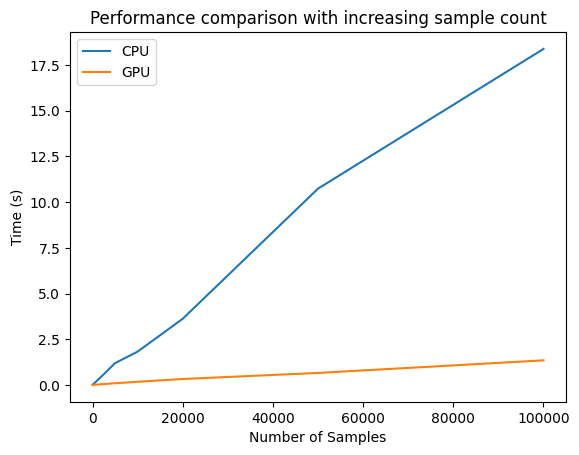

In [ ]:

# number of samples to test
samples = [1, 10, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000]

# arrays to store the results
times_cpu = []
times_gpu = []

# test for multiple sample sizes
for n_sample in samples:
  times_cpu.append(test_cpu(x_val, y_val, n_sample, -5.0, 5.0, 5)[0])
  times_gpu.append(test_gpu(x_val, y_val, n_sample, -5.0, 5.0, 5)[0])


plt.figure()
plt.plot(samples, times_cpu, label='CPU')
plt.plot(samples, times_gpu, label='GPU')
plt.xlabel('Number of Samples')
plt.ylabel('Time (s)')
plt.title('Performance comparison with increasing sample count')
plt.legend()
plt.show()

Took (CPU): 1.8564889430999756s (Samples = 10000)
Took (GPU full=False tiled=False): 0.1739950180053711s (Samples = 10000)
Took (CPU): 1.7901766300201416s (Samples = 10000)
Took (GPU full=False tiled=False): 0.16679120063781738s (Samples = 10000)
Took (CPU): 1.784076452255249s (Samples = 10000)
Took (GPU full=False tiled=False): 0.13363289833068848s (Samples = 10000)
Took (CPU): 2.166823387145996s (Samples = 10000)
Took (GPU full=False tiled=False): 0.19363975524902344s (Samples = 10000)
Took (CPU): 2.045203924179077s (Samples = 10000)
Took (GPU full=False tiled=False): 0.16875100135803223s (Samples = 10000)
Took (CPU): 1.758960485458374s (Samples = 10000)
Took (GPU full=False tiled=False): 0.1647779941558838s (Samples = 10000)
Took (CPU): 1.7673144340515137s (Samples = 10000)
Took (GPU full=False tiled=False): 0.13315463066101074s (Samples = 10000)
Took (CPU): 1.7771010398864746s (Samples = 10000)
Took (GPU full=False tiled=False): 0.1743755340576172s (Samples = 10000)
Took (CPU): 1.7

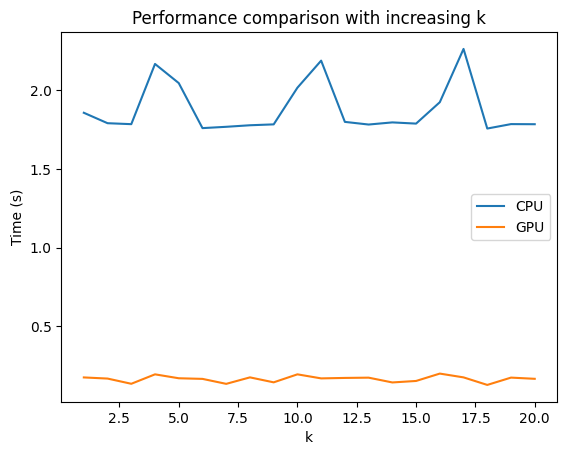

In [ ]:

# number of k to test
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

# arrays to store the results
times_cpu = []
times_gpu = []

n_sample = 10000
# test for multiple sample sizes
for k in k_values:
  times_cpu.append(test_cpu(x_val, y_val, 10000, -5.0, 5.0, k)[0])
  times_gpu.append(test_gpu(x_val, y_val, 10000, -5.0, 5.0, k)[0])


plt.figure()
plt.plot(k_values, times_cpu, label='CPU')
plt.plot(k_values, times_gpu, label='GPU')
plt.xlabel('k')
plt.ylabel('Time (s)')
plt.title('Performance comparison with increasing k')
plt.legend()
plt.show()

Took (GPU full=True tiled=True): 0.0028603076934814453s (Samples = 1)
Took (GPU full=False tiled=True): 0.0014848709106445312s (Samples = 1)
Took (GPU full=True tiled=False): 0.0013928413391113281s (Samples = 1)
Took (GPU full=False tiled=False): 0.0008704662322998047s (Samples = 1)
Took (GPU full=True tiled=True): 0.003914594650268555s (Samples = 10)
Took (GPU full=False tiled=True): 0.0009162425994873047s (Samples = 10)
Took (GPU full=True tiled=False): 0.004059553146362305s (Samples = 10)
Took (GPU full=False tiled=False): 0.0009019374847412109s (Samples = 10)
Took (GPU full=True tiled=True): 0.00646519660949707s (Samples = 20)
Took (GPU full=False tiled=True): 0.0009930133819580078s (Samples = 20)
Took (GPU full=True tiled=False): 0.0069730281829833984s (Samples = 20)
Took (GPU full=False tiled=False): 0.0009899139404296875s (Samples = 20)
Took (GPU full=True tiled=True): 0.01472163200378418s (Samples = 50)
Took (GPU full=False tiled=True): 0.0013544559478759766s (Samples = 50)
Too

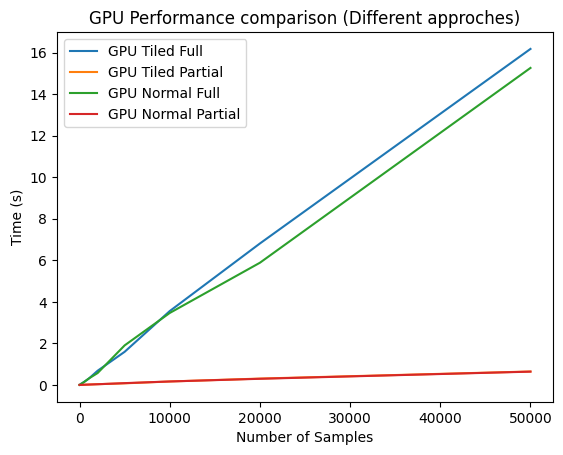

In [ ]:

x_val, y_val = parse_csv('MLoGPU_data3_train.csv')
samples = [1, 10, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]

times_gpu_tiled_full = []
times_gpu_tiled_partial = []
times_gpu_normal_full = []
times_gpu_normal_partial = []

batch_size = 8192
k = 5
sample_min = -5.0
sample_max = 5.0

for n_sample in samples:
  times_gpu_tiled_full.append(test_gpu(x_val, y_val, n_sample, sample_min, sample_max, k, batch_size, True, True)[0])
  times_gpu_tiled_partial.append(test_gpu(x_val, y_val, n_sample, sample_min, sample_max, k, batch_size, False, True)[0])
  times_gpu_normal_full.append(test_gpu(x_val, y_val, n_sample, sample_min, sample_max, k, batch_size, True, False)[0])
  times_gpu_normal_partial.append(test_gpu(x_val, y_val, n_sample, sample_min, sample_max, k, batch_size, False, False)[0])


plt.figure()
plt.plot(samples, times_gpu_tiled_full, label='GPU Tiled Full')
plt.plot(samples, times_gpu_tiled_partial, label='GPU Tiled Partial')
plt.plot(samples, times_gpu_normal_full, label='GPU Normal Full')
plt.plot(samples, times_gpu_normal_partial, label='GPU Normal Partial')
plt.xlabel('Number of Samples')
plt.ylabel('Time (s)')
plt.title('GPU Performance comparison (Different approches)')
plt.legend()
plt.show()

Took (GPU full=False tiled=True): 0.011190176010131836s (Samples = 1000)
Took (GPU full=False tiled=False): 0.01099252700805664s (Samples = 1000)
Took (GPU full=False tiled=True): 0.021528005599975586s (Samples = 2000)
Took (GPU full=False tiled=False): 0.02120828628540039s (Samples = 2000)
Took (GPU full=False tiled=True): 0.05536913871765137s (Samples = 5000)
Took (GPU full=False tiled=False): 0.05414533615112305s (Samples = 5000)
Took (GPU full=False tiled=True): 0.11197018623352051s (Samples = 10000)
Took (GPU full=False tiled=False): 0.10782456398010254s (Samples = 10000)
Took (GPU full=False tiled=True): 0.2252790927886963s (Samples = 20000)
Took (GPU full=False tiled=False): 0.21469998359680176s (Samples = 20000)
Took (GPU full=False tiled=True): 0.5404839515686035s (Samples = 50000)
Took (GPU full=False tiled=False): 0.5303182601928711s (Samples = 50000)
Took (GPU full=False tiled=True): 2.1677017211914062s (Samples = 200000)
Took (GPU full=False tiled=False): 2.296567678451538

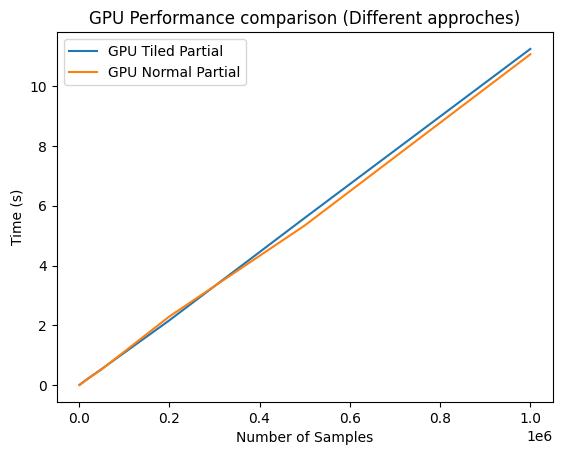

In [ ]:

x_val, y_val = parse_csv('MLoGPU_data3_train.csv')
samples = [1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 200_000, 500_000, 1_000_000]

times_gpu_tiled_partial = []
times_gpu_normal_partial = []

batch_size = 8192
k = 5
sample_min = -5.0
sample_max = 5.0

for n_sample in samples:
  times_gpu_tiled_partial.append(test_gpu(x_val, y_val, n_sample, sample_min, sample_max, k, batch_size, False, True)[0])
  times_gpu_normal_partial.append(test_gpu(x_val, y_val, n_sample, sample_min, sample_max, k, batch_size, False, False)[0])


plt.figure()
plt.plot(samples, times_gpu_tiled_partial, label='GPU Tiled Partial')
plt.plot(samples, times_gpu_normal_partial, label='GPU Normal Partial')
plt.xlabel('Number of Samples')
plt.ylabel('Time (s)')
plt.title('GPU Performance comparison (Different approches)')
plt.legend()
plt.show()

Testing batch size: 4
Took (CPU): 15.081197023391724s (Samples = 50000)
Took (GPU full=False tiled=False): 7.769158124923706s (Samples = 50000)
Testing batch size: 8
Took (CPU): 12.1237154006958s (Samples = 50000)
Took (GPU full=False tiled=False): 3.6888082027435303s (Samples = 50000)
Testing batch size: 16
Took (CPU): 9.867835283279419s (Samples = 50000)
Took (GPU full=False tiled=False): 1.9991631507873535s (Samples = 50000)
Testing batch size: 32
Took (CPU): 9.563823938369751s (Samples = 50000)
Took (GPU full=False tiled=False): 1.1709153652191162s (Samples = 50000)
Testing batch size: 64
Took (CPU): 9.136569738388062s (Samples = 50000)
Took (GPU full=False tiled=False): 1.0850393772125244s (Samples = 50000)
Testing batch size: 128
Took (CPU): 9.059316396713257s (Samples = 50000)
Took (GPU full=False tiled=False): 0.6365783214569092s (Samples = 50000)
Testing batch size: 256
Took (CPU): 10.797362327575684s (Samples = 50000)
Took (GPU full=False tiled=False): 0.6360282897949219s (Sa

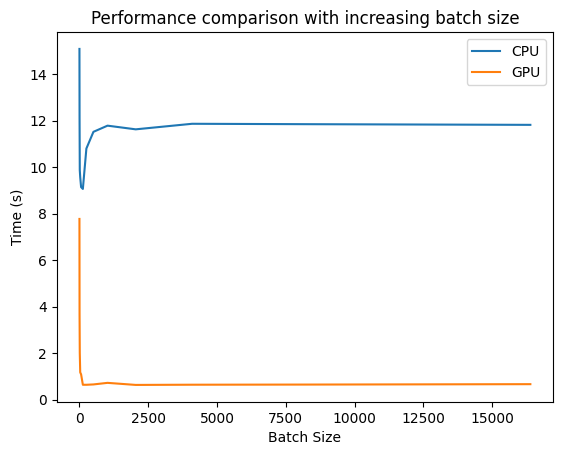

In [ ]:
# try to find the optimal batch size
batch_sizes = [4,8,16,32,64,128,256,512,1024,2048,4096,8192,16384]
samples = 50000

cpu_times = []
gpu_times = []
for batch_size in batch_sizes:
  print(f"Testing batch size: {batch_size}")
  took, _ = test_cpu(x_val, y_val, samples, -5.0, 5.0, 5, batch_size)
  cpu_times.append(took)
  took, _ = test_gpu(x_val, y_val, samples, -5.0, 5.0, 5, batch_size)
  gpu_times.append(took)

plt.figure()
plt.plot(batch_sizes, cpu_times, label='CPU')
plt.plot(batch_sizes, gpu_times, label='GPU')
plt.legend()
plt.xlabel('Batch Size')
plt.ylabel('Time (s)')
plt.title('Performance comparison with increasing batch size')
plt.show()



In [ ]:
split_index = int(0.7 * len(x_val))
x_train, y_train = x_val[:split_index], y_val[:split_index]
x_test, y_test = x_val[split_index:], y_val[split_index:]
print("Testing CPU implementation")
for k in range(1,10):
  results = knn_cpu(x_train, y_train, x_test, k=k, batch_size=32)
  accuracy = np.mean(results == y_test)
  print(f"Accuracy (k={k}): {accuracy:.4f}")

Testing CPU implementation
Accuracy (k=1): 0.5358
Accuracy (k=2): 0.5000
Accuracy (k=3): 0.4983
Accuracy (k=4): 0.5233
Accuracy (k=5): 0.5058
Accuracy (k=6): 0.5133
Accuracy (k=7): 0.5200
Accuracy (k=8): 0.5233
Accuracy (k=9): 0.5292
